In [1]:
import numpy as np
import os

base_path = "/Users/zyao/Downloads/wildfire-mitigation-model/results/"

files = {
    "initial": "initial_grid.csv",
    "baseline": "baseline.csv",
    "vegetation": "vegetation.csv",
    "hardening": "hardening.csv",
    "combined": "combined.csv"
}

data = {}
missing = []

for key, fname in files.items():
    path = os.path.join(base_path, fname)
    if os.path.exists(path):
        data[key] = np.loadtxt(path, delimiter=",")
    else:
        missing.append(fname)

results = {}

if "initial" in data:
    mask = data["initial"] == 1  # structure cells
    
    for key in ["baseline", "hardening", "vegetation", "combined"]:
        if key in data:
            values = data[key][mask]
            results[key] = {
                "min": float(np.min(values)),
                "max": float(np.max(values)),
                "mean": float(np.mean(values)),
                "std": float(np.std(values))
            }

results, missing

({'baseline': {'min': 0.024,
   'max': 0.366,
   'mean': 0.11756,
   'std': 0.06969193927564363},
  'hardening': {'min': 0.001,
   'max': 0.108,
   'mean': 0.01896,
   'std': 0.022180135256575872},
  'vegetation': {'min': 0.0,
   'max': 0.326,
   'mean': 0.0404,
   'std': 0.06382726690059665},
  'combined': {'min': 0.0,
   'max': 0.095,
   'mean': 0.00688,
   'std': 0.018556551403749566}},
 [])

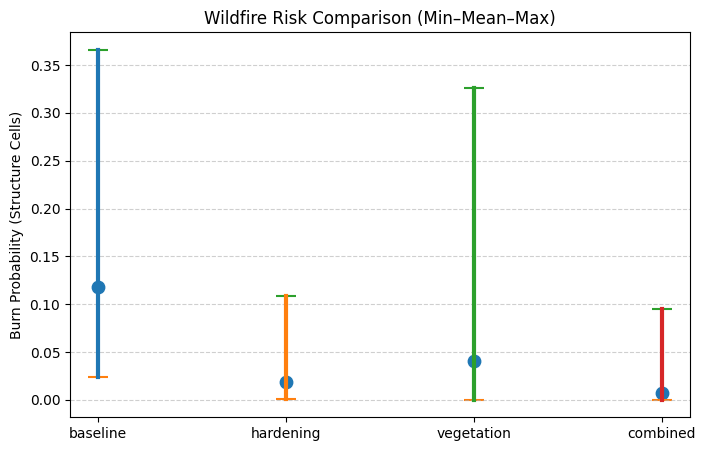

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Example: replace with your computed results
# ----------------------------
stats = results

labels = list(stats.keys())
x = np.arange(len(labels))

mins  = [stats[k]["min"] for k in labels]
means = [stats[k]["mean"] for k in labels]
maxs  = [stats[k]["max"] for k in labels]

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(8, 5))

# Vertical lines (min → max)
for i in range(len(x)):
    plt.plot([x[i], x[i]], [mins[i], maxs[i]], linewidth=3)

# Mean markers
plt.scatter(x, means, s=80)

# Optional: mark min/max points
plt.scatter(x, mins, marker="_", s=200)
plt.scatter(x, maxs, marker="_", s=200)

# Labels
plt.xticks(x, labels)
plt.ylabel("Burn Probability (Structure Cells)")
plt.title("Wildfire Risk Comparison (Min–Mean–Max)")

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save
plt.savefig("results/whisker_plot.png", dpi=300, bbox_inches='tight')

plt.show()